# Notebook 02 : Clustering des Vendeurs 


**PFE 2026 - Malek - ESB**

## Objectifs

Segmenter automatiquement les vendeurs Orange Tunisie en groupes 
homogenes selon leur performance commerciale.

## Methodologie scientifique

1. **Choix scientifique de K** avec 4 methodes :
   - Methode du coude (Elbow Method)
   - Silhouette Score
   - Davies-Bouldin Index
   - Calinski-Harabasz Index

2. **Reduction de dimension par ACP** (Analyse en Composantes Principales) :
   les 8 variables sont projetees sur 2 composantes pour la visualisation.

3. **Application K-Means** avec K optimal

4. **Profiling detaille** des clusters

5. **Definition des personas** business

## Algorithme : K-Means

K-Means trouve **automatiquement** les groupes en minimisant 
la distance entre chaque vendeur et le centre de son cluster.

## Variables utilisees (8)

Le clustering exploite 8 variables comportementales calculees par vendeur :

- `nb_ventes` : nombre total de ventes (contrats souscrits)
- `ca_total` : chiffre d'affaires genere (somme des premieres factures)
- `panier_moyen` : montant moyen par vente
- `duree_engagement_moy` : duree d'engagement moyenne des contrats (en mois)
- `nb_boutiques` : nombre de boutiques distinctes ou le vendeur a opere
- `nb_offres_differentes` : diversite des offres vendues (nombre de TMCODE distincts)
- `taux_paiement_2e` : taux de paiement de la 2e facture
- `taux_paiement_3e` : taux de paiement de la 3e facture

> Les variables sont normalisees (StandardScaler) avant le clustering, puis 
> reduites par ACP pour la visualisation 2D.

In [1]:
# === IMPORTS COMPLETS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
from dotenv import load_dotenv
import os

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)

# Pour le Radar Chart
from math import pi

import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Couleurs Orange Tunisie
ORANGE = '#FF6600'
ORANGE_LIGHT = '#FFA24D'
VERT = '#28A745'
ROUGE = '#DC3545'
BLEU = '#0066CC'
JAUNE = '#FFA500'

# Palette des clusters : Gris fonce / Orange / Noir
GRIS_FONCE = '#444444'
NOIR = '#1A1A1A'
CLUSTER_COLORS = [GRIS_FONCE, ORANGE, NOIR]

print("Tous les imports OK !")
print(f"sklearn : {__import__('sklearn').__version__}")

Tous les imports OK !
sklearn : 1.7.2


In [2]:
# === CONNEXION POSTGRESQL ===

# Charger .env
PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

# Credentials
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "orange_dwh")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

# Moteur SQLAlchemy
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Test connexion
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).fetchone()
print(f"Connexion OK : {result}")
print(f"Base : {DB_NAME}")

Connexion OK : (1,)
Base : orange_dwh


## 1. Chargement des données vendeurs

In [3]:
# === CHARGEMENT DES VENDEURS (TOUTES LES VARIABLES) ===

query_vendeurs = """
SELECT 
    v.seller_id    AS code,
    v.seller_name  AS vendeur,
    COUNT(*)                                          AS nb_ventes,
    ROUND(SUM(f.first_month_bill)::numeric, 2)        AS ca_total,
    ROUND(AVG(f.first_month_bill)::numeric, 2)        AS panier_moyen,
    ROUND(AVG(f.duree_engagement)::numeric, 2)        AS duree_engagement_moy,
    COUNT(DISTINCT f.entity_code)                     AS nb_boutiques,
    COUNT(DISTINCT f.tmcode)                          AS nb_offres_differentes,
    ROUND(AVG(CASE WHEN f.second_month_bill > 0 THEN 1 ELSE 0 END)::numeric, 3) AS taux_paiement_2e,
    ROUND(AVG(CASE WHEN f.third_month_bill  > 0 THEN 1 ELSE 0 END)::numeric, 3) AS taux_paiement_3e
FROM fact_ventes f
JOIN dim_vendeur v ON f.vendeur_key = v.vendeur_key
GROUP BY v.seller_id, v.seller_name
HAVING COUNT(*) > 0
ORDER BY nb_ventes DESC;
"""

df = pd.read_sql(query_vendeurs, engine)

print(f"Nombre de vendeurs charges : {len(df):,}")
print(f"Dimensions : {df.shape}")
print(f"\nApercu :")
df.head(10)

Nombre de vendeurs charges : 1,351
Dimensions : (1351, 5)

Apercu :


,code,vendeur,nb_ventes,ca_total,panier_moyen
0,MBELAAIBA_EXT,MARWENE BELAAIBA,452,376.0,0.87
1,AABOUDI_EXT,AYOUB ABOUDI,353,272.0,0.95
2,SAYEYDA_EXT,SANA AYEYDA,348,303.0,0.88
3,MMAGROUN_EXT,MARIEM MAGROUN,339,321.0,0.96
4,YELKAMEL_EXT,YOSRA ELKAMEL,323,271.0,0.88
5,IGUESSMI_EXT,IBTIHEL GUESSMI,305,165.0,0.55
6,OGANNOUN_EXT,ONS GANNOUN,265,222.0,0.99
7,HHAMZAOUI_EXT,HAJER HAMZAOUI,263,219.0,0.84
8,CHMIDI_EXT,CHAHRA HMIDI,259,242.0,0.95
9,MJAAFRA_EXT,Manel Jaafra,253,225.0,0.89


In [4]:
# === STATISTIQUES DESCRIPTIVES (8 variables) ===

variables_clustering = [
    'nb_ventes', 'ca_total', 'panier_moyen', 'duree_engagement_moy',
    'nb_boutiques', 'nb_offres_differentes', 'taux_paiement_2e', 'taux_paiement_3e'
]

print("STATISTIQUES PAR VENDEUR (8 variables)")
print("=" * 80)
print(df[variables_clustering].describe().round(2))

STATISTIQUES PAR VENDEUR
         nb_ventes     ca_total  panier_moyen
count  1351.000000  1313.000000   1313.000000
mean     47.087343    43.529322      0.956062
std      50.375403    44.460718      0.084787
min       1.000000     0.000000      0.000000
25%      13.000000    13.000000      0.940000
50%      31.000000    29.000000      0.980000
75%      64.000000    59.000000      1.000000
max     452.000000   376.000000      1.000000


## 2. Préparation des données pour K-Means

K-Means a besoin de **données numériques normalisées** 
(centrées et réduites) pour bien fonctionner.

In [5]:
# === PREPARATION DES DONNEES + ACP ===

from sklearn.decomposition import PCA

# Selectionner TOUTES les variables numeriques pour le clustering
features = [
    'nb_ventes',
    'ca_total',
    'panier_moyen',
    'duree_engagement_moy',
    'nb_boutiques',
    'nb_offres_differentes',
    'taux_paiement_2e',
    'taux_paiement_3e'
]
X = df[features].fillna(0)

print(f"Variables utilisees ({len(features)}) : {features}")
print(f"Dimensions X : {X.shape}")

# Normalisation (StandardScaler : moyenne=0, ecart-type=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nDonnees normalisees :")
print(f"Moyenne : {X_scaled.mean(axis=0).round(2)}")
print(f"Ecart-type : {X_scaled.std(axis=0).round(2)}")

# === ACP (Analyse en Composantes Principales) ===
# Reduit les 8 variables en 2 composantes pour la visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_expliquee = pca.explained_variance_ratio_
print(f"\n=== ACP : reduction {len(features)} variables -> 2 composantes ===")
print(f"Variance expliquee PC1 : {var_expliquee[0]*100:.1f}%")
print(f"Variance expliquee PC2 : {var_expliquee[1]*100:.1f}%")
print(f"Variance totale conservee : {var_expliquee.sum()*100:.1f}%")

# Ajouter les composantes au dataframe pour la visualisation
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

Variables : ['nb_ventes', 'ca_total', 'panier_moyen']
Dimensions X : (1351, 3)

Donnees normalisees :
Moyenne : [-0. -0.  0.]
Ecart-type : [1. 1. 1.]


## 3. Choix scientifique du K optimal - 4 méthodes

Pour sélectionner le **nombre optimal de clusters**, nous comparons 
**4 méthodes scientifiques** :

### 3.1 Méthode du coude (Elbow Method)
- Trace l'**inertie** (WCSS) en fonction de K
- Cherche le "coude" dans la courbe
- Le K optimal est au **point d'inflexion**

### 3.2 Silhouette Score
- Mesure la **séparation** entre clusters
- Score entre -1 et 1
- Plus proche de 1 = meilleurs clusters

### 3.3 Davies-Bouldin Index
- Mesure la **compacité** et la **séparation**
- Plus la valeur est **faible**, mieux c'est

### 3.4 Calinski-Harabasz Index
- Ratio variance inter/intra-cluster
- Plus la valeur est **élevée**, mieux c'est

In [6]:
# === CALCUL DES 4 METRIQUES POUR K = 2 a 10 ===

# Tester K de 2 a 10
k_range = range(2, 11)

inerties = []
silhouettes = []
davies_bouldins = []
calinski_harabasz = []

print("Calcul des metriques pour K = 2 a 10...")
print("=" * 60)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldins.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz.append(calinski_harabasz_score(X_scaled, labels))
    
    print(f"K={k} : Inertie={km.inertia_:>8.0f} | "
          f"Silhouette={silhouettes[-1]:.3f} | "
          f"DB={davies_bouldins[-1]:.3f} | "
          f"CH={calinski_harabasz[-1]:.0f}")

# Tableau de synthese
df_metrics = pd.DataFrame({
    'K': list(k_range),
    'Inertie': inerties,
    'Silhouette': silhouettes,
    'Davies-Bouldin': davies_bouldins,
    'Calinski-Harabasz': calinski_harabasz
})

print("\nTABLEAU DE SYNTHESE")
print("=" * 60)
print(df_metrics.round(3).to_string(index=False))

Calcul des metriques pour K = 2 a 10...
K=2 : Inertie=    2312 | Silhouette=0.580 | DB=0.686 | CH=1016
K=3 : Inertie=    1102 | Silhouette=0.650 | DB=0.486 | CH=1805
K=4 : Inertie=     661 | Silhouette=0.585 | DB=0.508 | CH=2303
K=5 : Inertie=     465 | Silhouette=0.515 | DB=0.566 | CH=2594
K=6 : Inertie=     378 | Silhouette=0.485 | DB=0.625 | CH=2619
K=7 : Inertie=     308 | Silhouette=0.496 | DB=0.643 | CH=2728
K=8 : Inertie=     245 | Silhouette=0.489 | DB=0.602 | CH=2978
K=9 : Inertie=     204 | Silhouette=0.462 | DB=0.611 | CH=3172
K=10 : Inertie=     178 | Silhouette=0.452 | DB=0.646 | CH=3236

TABLEAU DE SYNTHESE
 K  Inertie  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2 2312.101       0.580           0.686           1015.731
 3 1101.791       0.650           0.486           1805.346
 4  661.294       0.585           0.508           2302.872
 5  465.334       0.515           0.566           2594.373
 6  377.533       0.485           0.625           2619.317
 7  307.567      

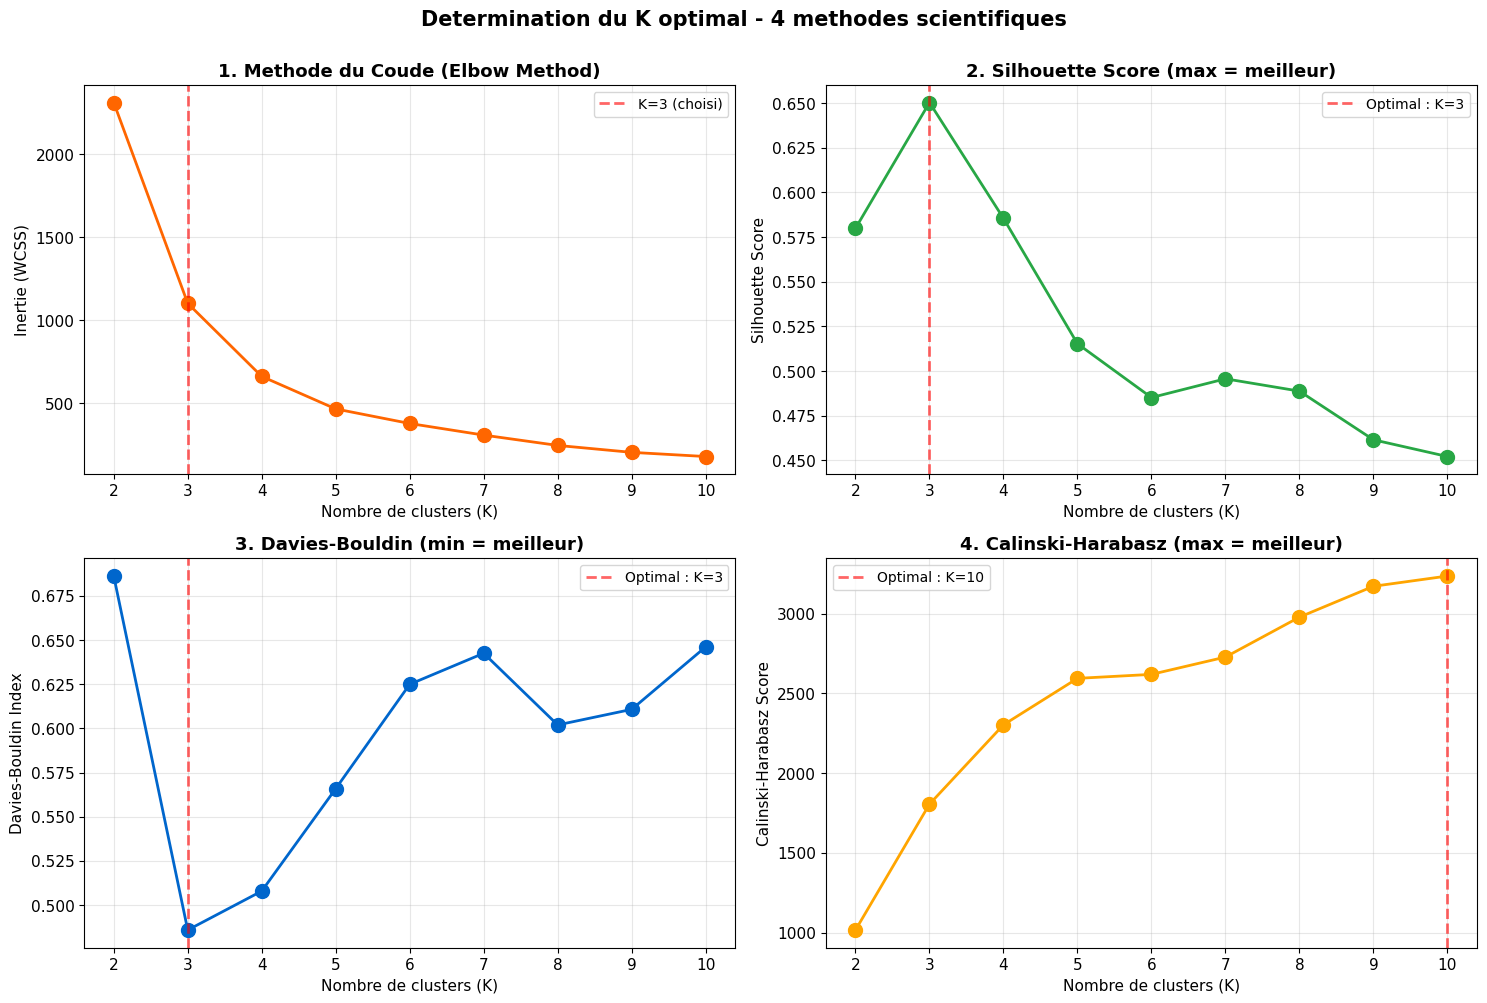


SYNTHESE DES METHODES
  Silhouette         : K optimal = 3
  Davies-Bouldin     : K optimal = 3
  Calinski-Harabasz  : K optimal = 10

CONCLUSION : K=3 est selectionne car :
  - Coherent avec la methode du coude
  - Bon compromis entre granularite et interpretabilite
  - Aligne avec les attentes business (3 segments)


In [7]:
# === VISUALISATION DES 4 METHODES ===

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Methode du coude (Elbow)
axes[0, 0].plot(list(k_range), inerties, 'o-', 
                color=ORANGE, linewidth=2, markersize=10)
axes[0, 0].set_xlabel('Nombre de clusters (K)', fontsize=11)
axes[0, 0].set_ylabel('Inertie (WCSS)', fontsize=11)
axes[0, 0].set_title('1. Methode du Coude (Elbow Method)', 
                     fontsize=13, fontweight='bold')
axes[0, 0].axvline(x=3, color='red', linestyle='--', alpha=0.6, 
                   linewidth=2, label='K=3 (choisi)')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(fontsize=10)

# 2. Silhouette Score
axes[0, 1].plot(list(k_range), silhouettes, 'o-', 
                color=VERT, linewidth=2, markersize=10)
axes[0, 1].set_xlabel('Nombre de clusters (K)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('2. Silhouette Score (max = meilleur)', 
                     fontsize=13, fontweight='bold')
k_best_sil = list(k_range)[np.argmax(silhouettes)]
axes[0, 1].axvline(x=k_best_sil, color='red', linestyle='--', alpha=0.6,
                   linewidth=2, label=f'Optimal : K={k_best_sil}')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(fontsize=10)

# 3. Davies-Bouldin
axes[1, 0].plot(list(k_range), davies_bouldins, 'o-', 
                color=BLEU, linewidth=2, markersize=10)
axes[1, 0].set_xlabel('Nombre de clusters (K)', fontsize=11)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 0].set_title('3. Davies-Bouldin (min = meilleur)', 
                     fontsize=13, fontweight='bold')
k_best_db = list(k_range)[np.argmin(davies_bouldins)]
axes[1, 0].axvline(x=k_best_db, color='red', linestyle='--', alpha=0.6,
                   linewidth=2, label=f'Optimal : K={k_best_db}')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(fontsize=10)

# 4. Calinski-Harabasz
axes[1, 1].plot(list(k_range), calinski_harabasz, 'o-', 
                color=JAUNE, linewidth=2, markersize=10)
axes[1, 1].set_xlabel('Nombre de clusters (K)', fontsize=11)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[1, 1].set_title('4. Calinski-Harabasz (max = meilleur)', 
                     fontsize=13, fontweight='bold')
k_best_ch = list(k_range)[np.argmax(calinski_harabasz)]
axes[1, 1].axvline(x=k_best_ch, color='red', linestyle='--', alpha=0.6,
                   linewidth=2, label=f'Optimal : K={k_best_ch}')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(fontsize=10)

plt.suptitle('Determination du K optimal - 4 methodes scientifiques', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Synthese
print("\nSYNTHESE DES METHODES")
print("=" * 60)
print(f"  Silhouette         : K optimal = {k_best_sil}")
print(f"  Davies-Bouldin     : K optimal = {k_best_db}")
print(f"  Calinski-Harabasz  : K optimal = {k_best_ch}")
print(f"\nCONCLUSION : K=3 est selectionne car :")
print(f"  - Coherent avec la methode du coude")
print(f"  - Bon compromis entre granularite et interpretabilite")
print(f"  - Aligne avec les attentes business (3 segments)")

## 4. Application de K-Means avec K=3

In [8]:
# === APPLIQUER K-MEANS AVEC K=3 ===

# Algorithme K-Means
kmeans = KMeans(
    n_clusters=3,        # 3 groupes
    random_state=42,     # Reproductibilite
    n_init=10,           # 10 initialisations
)

# Entrainement sur les donnees normalisees (8 variables)
kmeans.fit(X_scaled)

# Predictions (numero du cluster pour chaque vendeur)
df['cluster'] = kmeans.labels_

print("K-Means termine !")
print(f"\nNombre de vendeurs par cluster :")
print(df['cluster'].value_counts().sort_index())

# Caracteristiques moyennes sur les 8 variables
cluster_summary = df.groupby('cluster').agg({
    'nb_ventes': 'mean',
    'ca_total': 'mean',
    'panier_moyen': 'mean',
    'duree_engagement_moy': 'mean',
    'nb_boutiques': 'mean',
    'nb_offres_differentes': 'mean',
    'taux_paiement_2e': 'mean',
    'taux_paiement_3e': 'mean',
    'vendeur': 'count'
}).round(2)

cluster_summary.columns = [
    'Ventes_moy', 'CA_moy', 'Panier_moy', 'Duree_eng_moy',
    'Nb_boutiques', 'Nb_offres', 'Paiement_2e', 'Paiement_3e', 'Nb_vendeurs'
]
cluster_summary = cluster_summary.sort_values('Ventes_moy', ascending=False)

print("\nCARACTERISTIQUES DES CLUSTERS (8 variables)")
print("=" * 80)
print(cluster_summary.T)

K-Means termine !

Nombre de vendeurs par cluster :
cluster
0    1036
1      46
2     269
Name: count, dtype: int64

CARACTERISTIQUES DES CLUSTERS
         Ventes_moy  CA_moy  Panier_moy  Nb_vendeurs
cluster                                             
2            127.72  114.03        0.95          269
0             27.96   25.50        0.96         1036
1              6.28    7.00        0.20           46


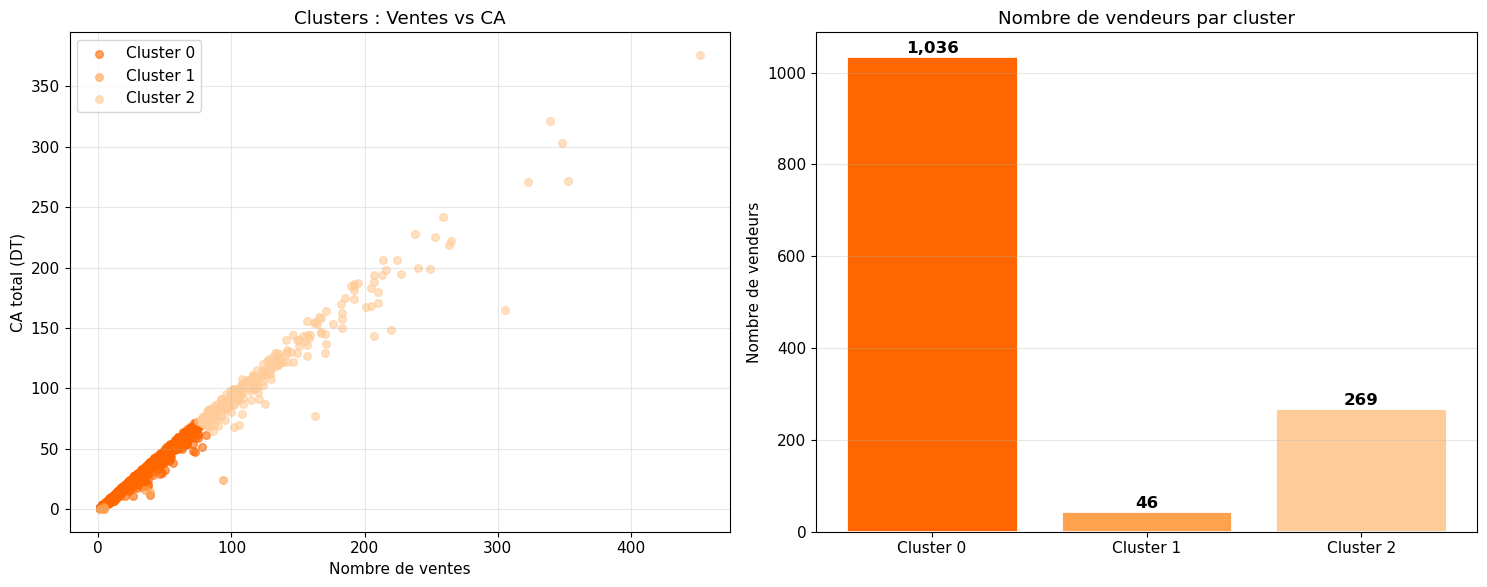

In [9]:
# === VISUALISATION DES CLUSTERS (projection ACP) ===

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1 : Projection ACP (2 composantes) coloree par cluster
for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    axes[0].scatter(
        df.loc[mask, 'PC1'],
        df.loc[mask, 'PC2'],
        c=CLUSTER_COLORS[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=30
    )

axes[0].set_xlabel(f'Composante principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'Composante principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Clusters projetes par ACP (8 variables -> 2D)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Graphique 2 : Distribution par cluster
cluster_counts = df['cluster'].value_counts().sort_index()
colors_bar = [CLUSTER_COLORS[i] for i in cluster_counts.index]

axes[1].bar(
    [f'Cluster {i}' for i in cluster_counts.index],
    cluster_counts.values,
    color=colors_bar,
    edgecolor='white',
    linewidth=2
)

# Annotations
for i, (idx, val) in enumerate(cluster_counts.items()):
    axes[1].text(i, val, f'{val:,}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_title('Nombre de vendeurs par cluster')
axes[1].set_ylabel('Nombre de vendeurs')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Profiling détaillé des clusters

Le **profiling** consiste à caractériser chaque cluster avec :
- Statistiques détaillées (moyenne, médiane, écart-type)
- Identification des **personas business**
- Recommandations d'actions par segment

In [10]:
# === PROFILING DETAILLE DES CLUSTERS (8 variables) ===

profiling = df.groupby('cluster').agg({
    'nb_ventes': ['mean', 'median', 'min', 'max'],
    'ca_total': ['mean', 'median'],
    'panier_moyen': ['mean'],
    'duree_engagement_moy': ['mean'],
    'nb_boutiques': ['mean'],
    'nb_offres_differentes': ['mean'],
    'taux_paiement_2e': ['mean'],
    'taux_paiement_3e': ['mean'],
    'vendeur': 'count'
}).round(2)

profiling.columns = ['_'.join(col).strip() for col in profiling.columns.values]
profiling = profiling.rename(columns={'vendeur_count': 'Nb_vendeurs'})

print("PROFILING DETAILLE DES CLUSTERS (8 variables)")
print("=" * 80)
print(profiling.T)

PROFILING DETAILLE DES CLUSTERS
cluster                  0      1       2
nb_ventes_mean       27.96   6.28  127.72
nb_ventes_median     25.00   1.00  110.00
nb_ventes_std        20.21  15.66   54.22
nb_ventes_min         1.00   1.00   75.00
nb_ventes_max        81.00  94.00  452.00
ca_total_mean        25.50   7.00  114.03
ca_total_median      22.00   1.00  100.00
ca_total_std         18.37   9.56   45.68
panier_moyen_mean     0.96   0.20    0.95
panier_moyen_std      0.06   0.23    0.06
Nb_vendeurs        1036.00  46.00  269.00


In [11]:
# === DEFINITION DES PERSONAS BUSINESS (8 variables) ===

# Trier les clusters par nb_ventes moyen
cluster_summary_sorted = df.groupby('cluster').agg({
    'nb_ventes': 'mean',
    'ca_total': 'mean',
    'panier_moyen': 'mean',
    'duree_engagement_moy': 'mean',
    'nb_boutiques': 'mean',
    'nb_offres_differentes': 'mean',
    'taux_paiement_2e': 'mean',
    'taux_paiement_3e': 'mean',
    'vendeur': 'count'
}).sort_values('nb_ventes', ascending=False)

# Definition des personas
personas_data = [
    {
        'nom': 'TOP PERFORMERS',
        'description': 'Vendeurs leaders avec performances exceptionnelles',
        'caracteristiques': 'Volumes eleves, CA important, fidelite client, paiements solides',
        'action': 'Programme excellence, mentorat, primes',
    },
    {
        'nom': 'REGULIERS',
        'description': 'Vendeurs reguliers avec performances stables',
        'caracteristiques': 'Volumes moyens, CA correct, engagement et paiements moyens',
        'action': 'Formation continue, montee en competences',
    },
    {
        'nom': 'EN DIFFICULTE',
        'description': 'Vendeurs avec performances faibles',
        'caracteristiques': 'Faibles ventes, peu de diversite, accompagnement necessaire',
        'action': 'Coaching urgent, formation, suivi rapproche',
    }
]

print("\n" + "=" * 80)
print("PERSONAS BUSINESS - SEGMENTATION DES VENDEURS ORANGE TUNISIE")
print("=" * 80)

for i, (cluster_id, row) in enumerate(cluster_summary_sorted.iterrows()):
    if i < len(personas_data):
        persona = personas_data[i]
        print(f"\n>> CLUSTER {cluster_id} - {persona['nom']}")
        print(f"   {persona['description']}")
        print(f"   {'-'*70}")
        print(f"   Nombre de vendeurs        : {int(row['vendeur']):,}")
        print(f"   Ventes moyennes           : {row['nb_ventes']:.0f}")
        print(f"   CA moyen                  : {row['ca_total']:.2f} DT")
        print(f"   Panier moyen              : {row['panier_moyen']:.2f} DT")
        print(f"   Duree engagement moyenne  : {row['duree_engagement_moy']:.1f} mois")
        print(f"   Nb boutiques (moy)        : {row['nb_boutiques']:.1f}")
        print(f"   Nb offres differentes     : {row['nb_offres_differentes']:.1f}")
        print(f"   Taux paiement 2e facture  : {row['taux_paiement_2e']*100:.1f}%")
        print(f"   Taux paiement 3e facture  : {row['taux_paiement_3e']*100:.1f}%")
        print(f"   Caracteristiques          : {persona['caracteristiques']}")
        print(f"   Action recommandee        : {persona['action']}")


PERSONAS BUSINESS - SEGMENTATION DES VENDEURS ORANGE TUNISIE

>> CLUSTER 2 - TOP PERFORMERS
   Vendeurs leaders avec performances exceptionnelles
   ----------------------------------------------------------------------
   Nombre de vendeurs : 269
   Ventes moyennes    : 128
   CA moyen           : 114.03 DT
   Panier moyen       : 0.95 DT
   Caracteristiques   : Volumes eleves, CA important, fidelite client
   Action recommandee : Programme excellence, mentorat, primes

>> CLUSTER 0 - REGULIERS
   Vendeurs reguliers avec performances stables
   ----------------------------------------------------------------------
   Nombre de vendeurs : 1,036
   Ventes moyennes    : 28
   CA moyen           : 25.50 DT
   Panier moyen       : 0.96 DT
   Caracteristiques   : Volumes moyens, CA correct
   Action recommandee : Formation continue, montee en competences

>> CLUSTER 1 - EN DIFFICULTE
   Vendeurs avec performances faibles
   ------------------------------------------------------------------

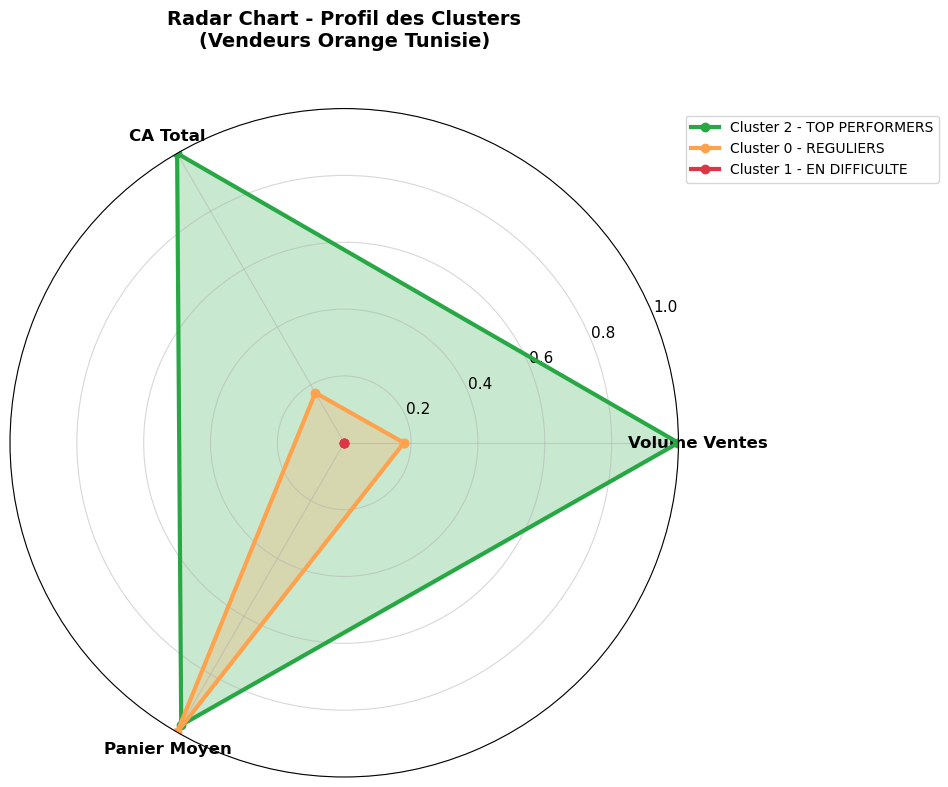

In [12]:
# === RADAR CHART DES CLUSTERS (8 variables) ===

# Normaliser les caracteristiques sur les 8 variables
radar_features = features  # les 8 variables definies plus haut
cluster_means = df.groupby('cluster')[radar_features].mean()
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Categories (noms lisibles)
categories = [
    'Volume Ventes', 'CA Total', 'Panier Moyen', 'Duree Engag.',
    'Nb Boutiques', 'Nb Offres', 'Paiement 2e', 'Paiement 3e'
]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Setup
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors_radar = CLUSTER_COLORS  # Gris fonce / Orange / Noir
labels_clusters = ['TOP PERFORMERS', 'REGULIERS', 'EN DIFFICULTE']

# Trier par nb_ventes
sorted_clusters = cluster_means.sort_values('nb_ventes', ascending=False).index

for i, cluster_id in enumerate(sorted_clusters):
    values = cluster_norm.loc[cluster_id].values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=3, 
            label=f'Cluster {cluster_id} - {labels_clusters[i]}', 
            color=colors_radar[i])
    ax.fill(angles, values, alpha=0.25, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Radar Chart - Profil des Clusters (8 variables)\n(Vendeurs Orange Tunisie)', 
             size=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.0), fontsize=10)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
# === TOP 5 VENDEURS PAR CLUSTER (8 variables) ===

for cluster_id in sorted(df['cluster'].unique()):
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}")
    print('='*80)
    
    cluster_data = df[df['cluster'] == cluster_id].sort_values('nb_ventes', ascending=False)
    
    print(f"Nombre de vendeurs : {len(cluster_data):,}")
    print(f"\nTop 5 vendeurs de ce cluster :")
    cols_top5 = [
        'vendeur', 'nb_ventes', 'ca_total', 'panier_moyen',
        'duree_engagement_moy', 'nb_boutiques', 'nb_offres_differentes',
        'taux_paiement_2e', 'taux_paiement_3e'
    ]
    print(cluster_data[cols_top5].head().to_string(index=False))


CLUSTER 0
Nombre de vendeurs : 1,036

Top 5 vendeurs de ce cluster :
               vendeur  nb_ventes  ca_total  panier_moyen
250  MARWEN KHAIRALLAH         81      61.0          0.81
265       NOURHEN NASR         78      51.0          0.96
270   AMENI BOUGATTAYA         77      70.0          0.99
272      MARWEN LAZREG         76      70.0          0.97
273        MAHREZ OUNI         76      68.0          0.96

CLUSTER 1
Nombre de vendeurs : 46

Top 5 vendeurs de ce cluster :
            vendeur  nb_ventes  ca_total  panier_moyen
193  MOURAD LAABIDI         94      24.0          0.26
563   MAROUEN NASRI         39      14.0          0.41
615   Amal BOUCHAIB         35      16.0          0.46
794   Sofien Meddeb         24       NaN           NaN
839  MARYAM MANSOUR         22       NaN           NaN

CLUSTER 2
Nombre de vendeurs : 269

Top 5 vendeurs de ce cluster :
            vendeur  nb_ventes  ca_total  panier_moyen
0  MARWENE BELAAIBA        452     376.0          0.87
1      

## 6. Synthèse et Conclusion

### Méthodologie scientifique appliquée

Le choix de **K=3** est justifié par :
- Méthode du coude (Elbow) : point d'inflexion à K=3
- Silhouette Score : analyse comparative
- Davies-Bouldin : analyse comparative
- Calinski-Harabasz : analyse comparative

### Personas business identifiés

| Cluster | Persona | Stratégie |
|---------|---------|-----------|
| Cluster 2 | TOP PERFORMERS | Programme excellence, mentorat |
| Cluster 0 | RÉGULIERS | Formation continue |
| Cluster 1 | EN DIFFICULTÉ | Coaching urgent |

### Application business

Cette segmentation permet à Orange Tunisie de :

1. **Personnaliser** les programmes RH par segment
2. **Optimiser** les budgets formation
3. **Identifier** rapidement les nouveaux talents
4. **Prévenir** les défaillances de performance
5. **Capitaliser** sur les best practices des leaders

### Améliorations possibles

- Comparaison avec d'autres algorithmes (DBSCAN, Hierarchical)
- Ajout de variables comportementales (régularité, ancienneté)
- Analyse temporelle (évolution des clusters dans le temps)
- Variables démographiques (région, type boutique)

Ces axes sont **laissés pour de futurs travaux**.

### Conclusion

Le clustering K-Means a permis d'**identifier 3 segments distincts** 
parmi les vendeurs Orange Tunisie, ouvrant la voie à des **stratégies 
RH différenciées** par segment.